# Conclusiones Importantes Del Proyecto Everest

Este notebook resume graficamente los hallazgos mas relevantes del analisis y del modelado sobre la base Himalaya ya depurada.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 7)

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent

OUTPUTS = ROOT / 'outputs'

master = pd.read_csv(OUTPUTS / 'himalaya_master_clean.csv', low_memory=False)
occ_group = pd.read_csv(OUTPUTS / 'occupation_group_summary.csv')
occ_raw = pd.read_csv(OUTPUTS / 'occupation_raw_summary.csv')
region = pd.read_csv(OUTPUTS / 'region_summary.csv')
catboost_preds = pd.read_csv(OUTPUTS / 'catboost_predictions.csv')

with open(OUTPUTS / 'data_quality_summary.json', 'r', encoding='utf-8') as f:
    quality = json.load(f)
with open(OUTPUTS / 'baseline_metrics.json', 'r', encoding='utf-8') as f:
    baseline_metrics = json.load(f)
with open(OUTPUTS / 'catboost_metrics.json', 'r', encoding='utf-8') as f:
    catboost_metrics = json.load(f)

def pct(x):
    return f"{100*x:.1f}%"


In [2]:
rows = quality['rows_master']
outcomes = pd.Series(quality['outcome_4_counts']).sort_values(ascending=False)
age_valid = quality['age_valid_count'] / rows
age_missing = quality['age_missing_count'] / rows
age_invalid = quality['age_invalid_count'] / rows
occ_missing = quality['occupation_missing_count'] / rows

best_region_summit = region.loc[region['summit_rate'].idxmax()]
worst_region_summit = region.loc[region['summit_rate'].idxmin()]
worst_region_death = region.loc[region['death_rate'].idxmax()]

occ_focus = occ_group[occ_group['n'] >= 1500].copy()
best_occ_summit = occ_focus.loc[occ_focus['summit_rate'].idxmax()]
worst_occ_summit = occ_focus.loc[occ_focus['summit_rate'].idxmin()]

baseline_test = baseline_metrics['splits']['test']
cat_test = catboost_metrics['test_uncalibrated']
cat_test_cal = catboost_metrics['test_calibrated']

summary_md = f"""
## Resumen ejecutivo

- La base final contiene **{rows:,}** registros montanista-expedicion.
- El resultado mas frecuente es **{outcomes.index[0]}** con **{outcomes.iloc[0]:,} casos** ({pct(outcomes.iloc[0] / rows)}).
- La edad utilizable cubre **{pct(age_valid)}** de la base; falta en **{pct(age_missing)}** y queda fuera de rango en **{pct(age_invalid)}**.
- La ocupacion original falta en **{pct(occ_missing)}** de los registros, por lo que su interpretacion requiere cautela.
- La region con mayor tasa de cima es **{best_region_summit['peak_region']}** ({pct(best_region_summit['summit_rate'])}).
- La region con menor tasa de cima es **{worst_region_summit['peak_region']}** ({pct(worst_region_summit['summit_rate'])}).
- La mayor tasa de muerte aparece en **{worst_region_death['peak_region']}** ({pct(worst_region_death['death_rate'])}).
- Entre los grupos ocupacionales con volumen relevante, la mayor tasa de cima es **{best_occ_summit['occupation_group']}** ({pct(best_occ_summit['summit_rate'])}) y la menor es **{worst_occ_summit['occupation_group']}** ({pct(worst_occ_summit['summit_rate'])}).
- En test, **CatBoost** supera al baseline en prediccion de cima: balanced accuracy **{cat_test['summit_metrics']['balanced_accuracy']:.3f}** vs **{baseline_test['summit_metrics']['balanced_accuracy']:.3f}**.
- En test, ningun modelo resuelve bien la muerte: el problema sigue fuertemente limitado por el desbalance extremo de clase.
"""

display(Markdown(summary_md))


## Resumen ejecutivo

- La base final contiene **89,000** registros montanista-expedicion.
- El resultado mas frecuente es **abandona_vive** con **51,173 casos** (57.5%).
- La edad utilizable cubre **91.1%** de la base; falta en **6.1%** y queda fuera de rango en **2.8%**.
- La ocupacion original falta en **34.5%** de los registros, por lo que su interpretacion requiere cautela.
- La region con mayor tasa de cima es **Khumbu-Rolwaling-Makalu** (45.9%).
- La region con menor tasa de cima es **Kanjiroba-Far West** (24.5%).
- La mayor tasa de muerte aparece en **Dhaulagiri-Mukut** (2.3%).
- Entre los grupos ocupacionales con volumen relevante, la mayor tasa de cima es **unknown** (59.1%) y la menor es **media_photo** (23.1%).
- En test, **CatBoost** supera al baseline en prediccion de cima: balanced accuracy **0.662** vs **0.615**.
- En test, ningun modelo resuelve bien la muerte: el problema sigue fuertemente limitado por el desbalance extremo de clase.


C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_17412\432040867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outcome_df, x='outcome', y='share', palette='crest', ax=ax)


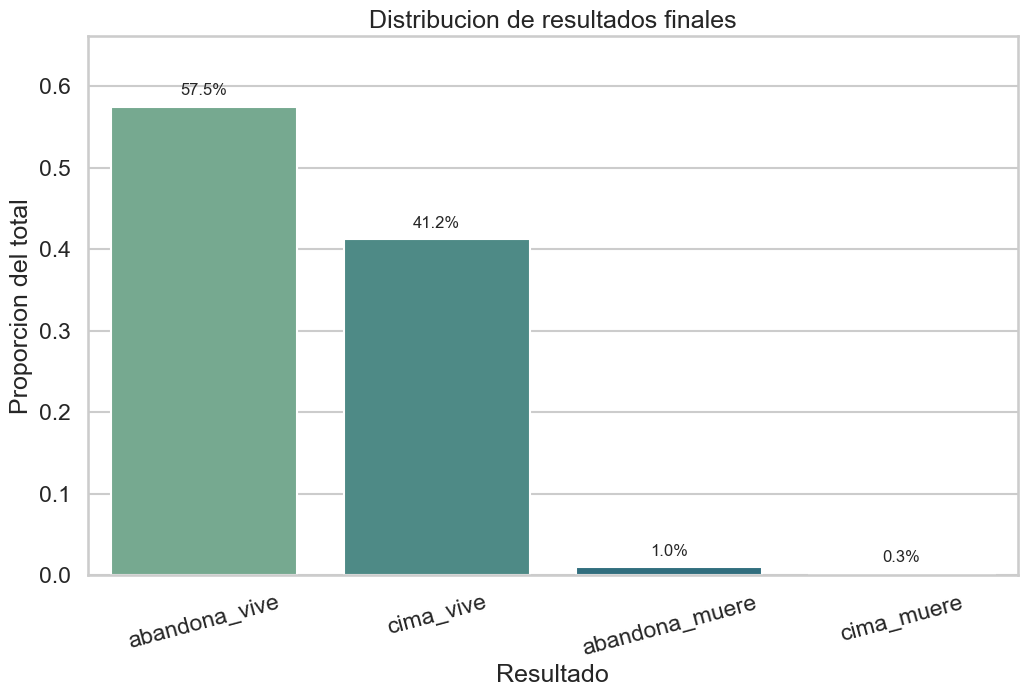

In [3]:
outcome_df = outcomes.rename_axis('outcome').reset_index(name='n')
outcome_df['share'] = outcome_df['n'] / outcome_df['n'].sum()

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=outcome_df, x='outcome', y='share', palette='crest', ax=ax)
ax.set_title('Distribucion de resultados finales')
ax.set_xlabel('Resultado')
ax.set_ylabel('Proporcion del total')
ax.set_ylim(0, outcome_df['share'].max() * 1.15)
for i, row in outcome_df.iterrows():
    ax.text(i, row['share'] + 0.01, pct(row['share']), ha='center', va='bottom', fontsize=12)
plt.xticks(rotation=15)
plt.show()

## Lectura clave

La base esta dominada por dos resultados: `abandona_vive` y `cima_vive`. Las muertes son eventos muy raros, lo que explica por que los modelos tienen dificultades para capturar bien esas clases.

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_17412\3657997260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_plot, y='peak_region', x='summit_rate', palette='YlGn', ax=axes[0])
C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_17412\3657997260.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_plot, y='peak_region', x='death_rate', palette='OrRd', ax=axes[1])


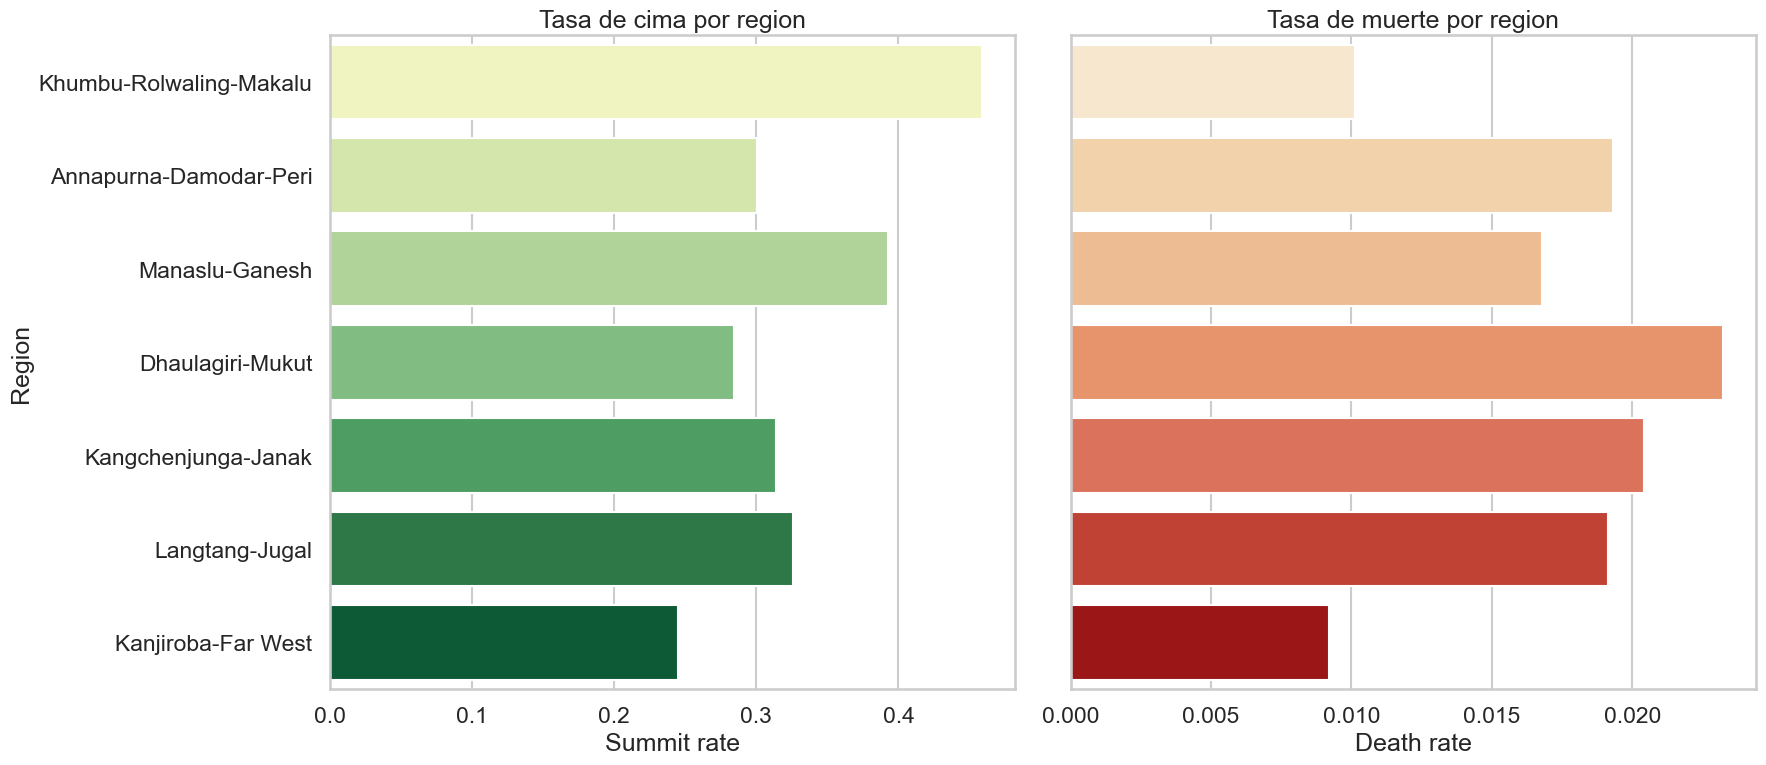

In [4]:
region_plot = region.sort_values('members', ascending=False).copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

sns.barplot(data=region_plot, y='peak_region', x='summit_rate', palette='YlGn', ax=axes[0])
axes[0].set_title('Tasa de cima por region')
axes[0].set_xlabel('Summit rate')
axes[0].set_ylabel('Region')

sns.barplot(data=region_plot, y='peak_region', x='death_rate', palette='OrRd', ax=axes[1])
axes[1].set_title('Tasa de muerte por region')
axes[1].set_xlabel('Death rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Lectura clave

Khumbu-Rolwaling-Makalu concentra la mayor cantidad de miembros y tambien la mayor tasa de cima. En contraste, Dhaulagiri-Mukut y Kangchenjunga-Janak muestran tasas de muerte relativamente mas altas y tasas de cima mas bajas.

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_17412\2426539412.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=occ_plot, y='occupation_group', x='summit_rate', palette='Blues', ax=axes[0])
C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_17412\2426539412.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=occ_plot.sort_values('death_rate', ascending=False), y='occupation_group', x='death_rate', palette='Reds', ax=axes[1])


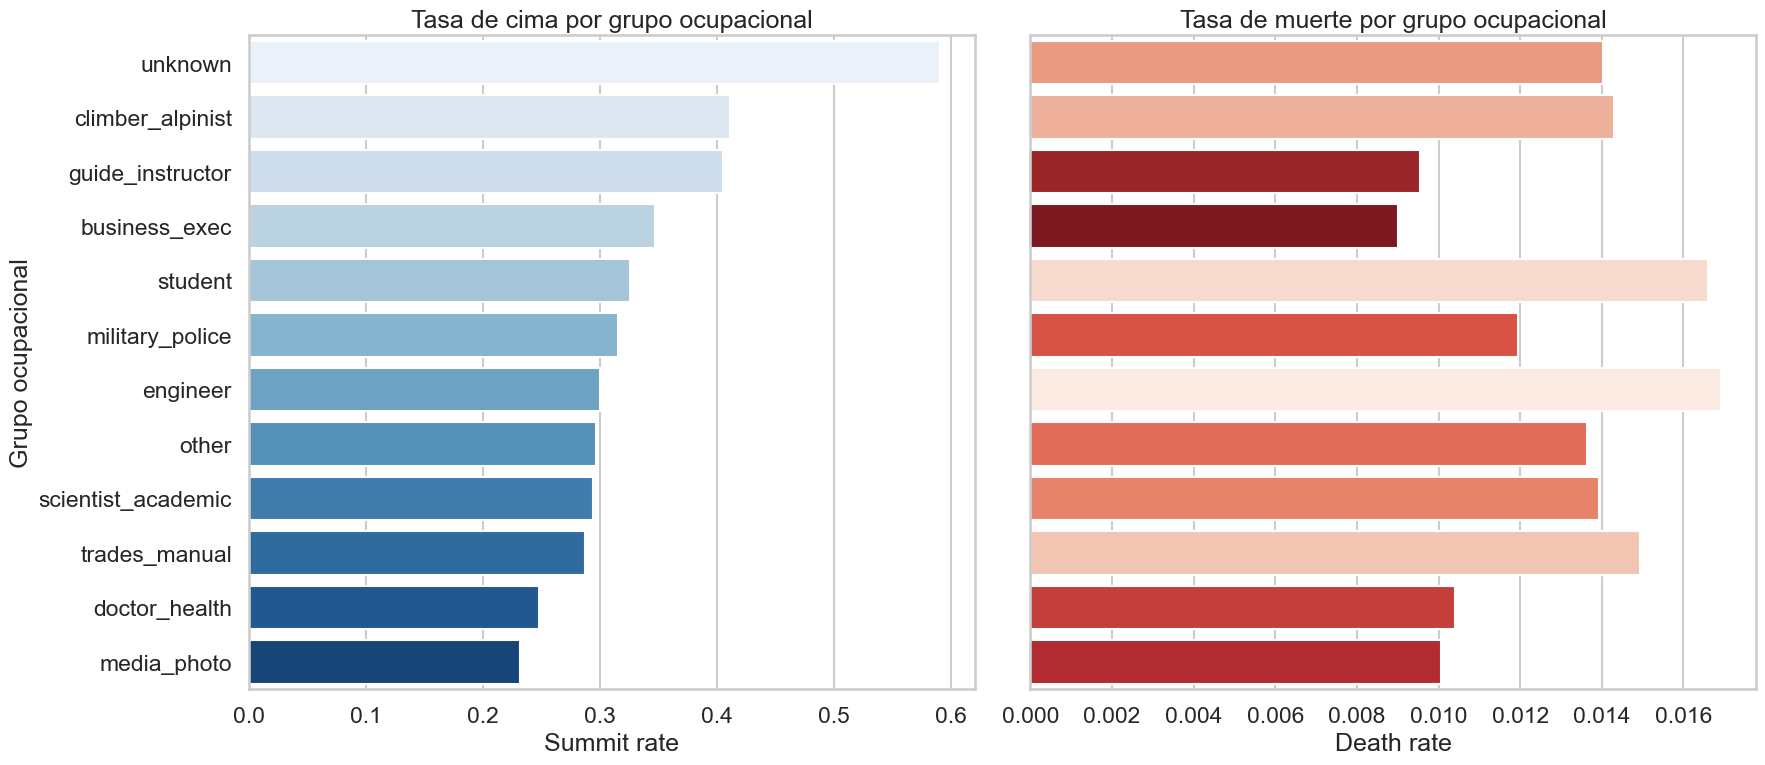

In [5]:
occ_plot = occ_group[occ_group['n'] >= 1500].sort_values('summit_rate', ascending=False).copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

sns.barplot(data=occ_plot, y='occupation_group', x='summit_rate', palette='Blues', ax=axes[0])
axes[0].set_title('Tasa de cima por grupo ocupacional')
axes[0].set_xlabel('Summit rate')
axes[0].set_ylabel('Grupo ocupacional')

sns.barplot(data=occ_plot.sort_values('death_rate', ascending=False), y='occupation_group', x='death_rate', palette='Reds', ax=axes[1])
axes[1].set_title('Tasa de muerte por grupo ocupacional')
axes[1].set_xlabel('Death rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Lectura clave

Los grupos `guide_instructor` y `climber_alpinist` muestran mejores tasas de cima que el resto. Aun asi, la columna de ocupacion tiene bastante faltante, por lo que esta relacion debe leerse como indicio descriptivo y no como verdad causal cerrada.

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_17412\401435225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_occ_raw, y='occupation_raw_clean', x='summit_rate', palette='mako', ax=ax)


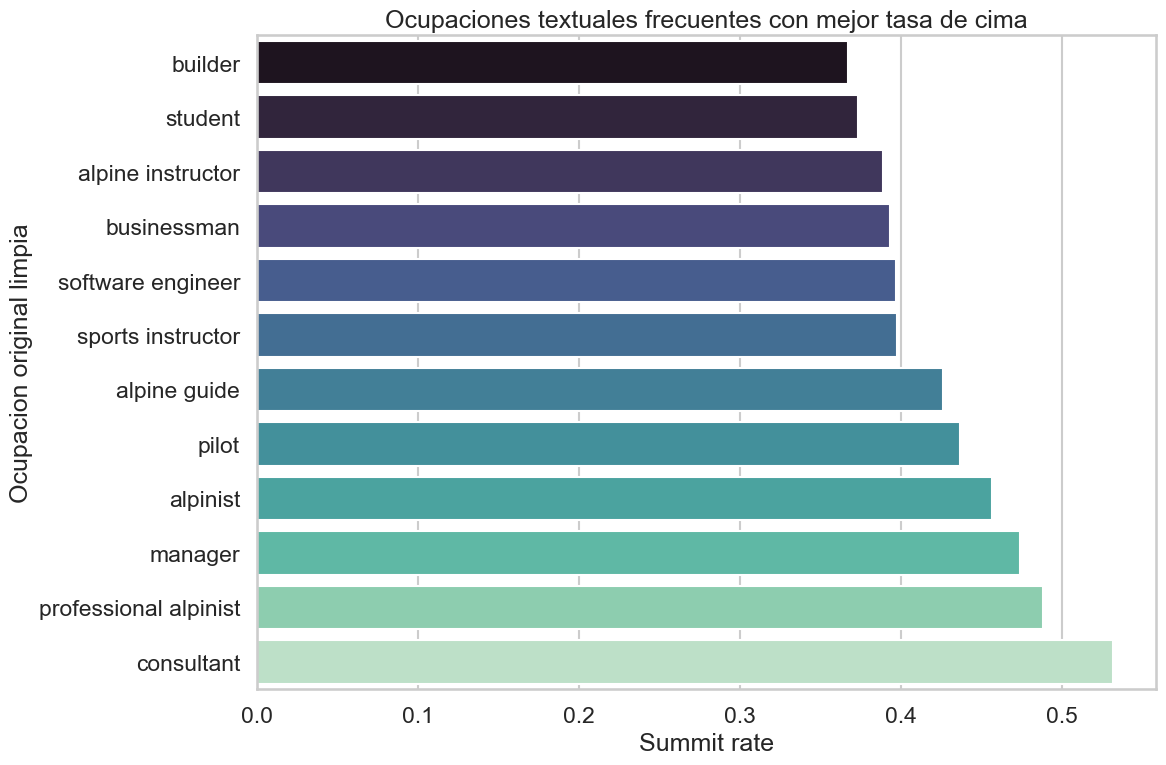

In [6]:
top_occ_raw = occ_raw.head(12).sort_values('summit_rate', ascending=True)
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_occ_raw, y='occupation_raw_clean', x='summit_rate', palette='mako', ax=ax)
ax.set_title('Ocupaciones textuales frecuentes con mejor tasa de cima')
ax.set_xlabel('Summit rate')
ax.set_ylabel('Ocupacion original limpia')
plt.tight_layout()
plt.show()

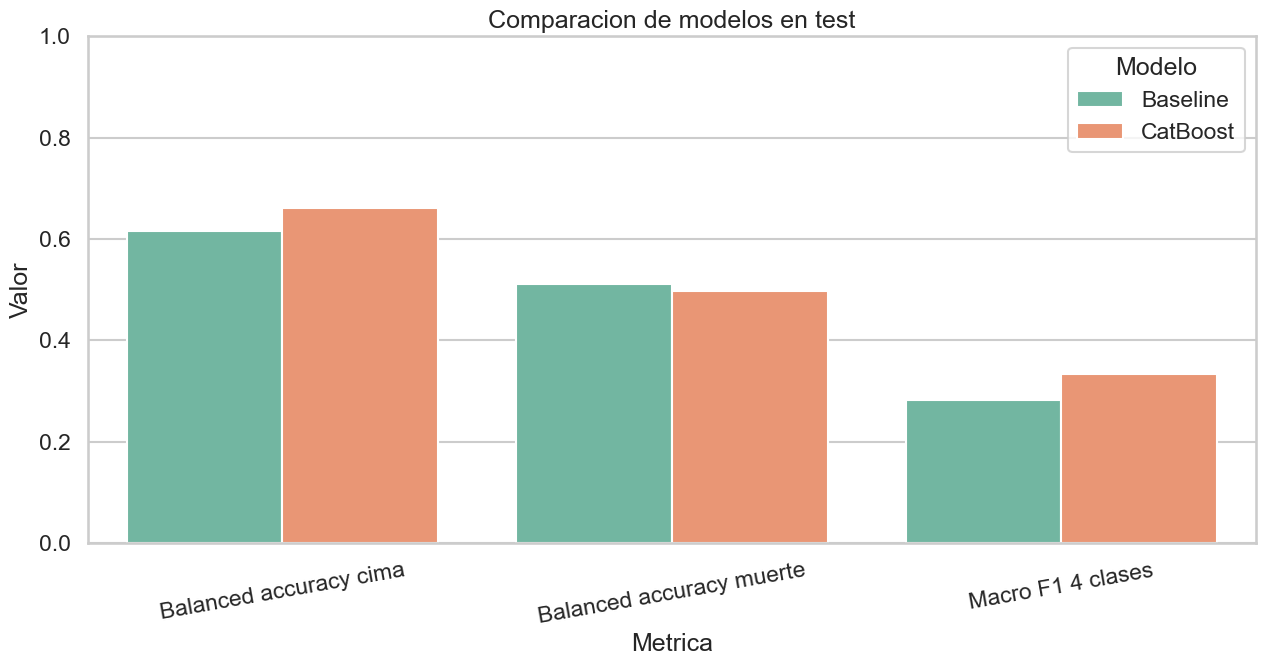

In [7]:
comparison = pd.DataFrame([
    {
        'model': 'Baseline',
        'summit_bal_acc': baseline_test['summit_metrics']['balanced_accuracy'],
        'death_bal_acc': baseline_test['death_metrics']['balanced_accuracy'],
        'outcome_macro_f1': baseline_test['outcome_4_metrics']['macro_f1'],
    },
    {
        'model': 'CatBoost',
        'summit_bal_acc': cat_test['summit_metrics']['balanced_accuracy'],
        'death_bal_acc': cat_test['death_metrics']['balanced_accuracy'],
        'outcome_macro_f1': cat_test['outcome_4_metrics']['macro_f1'],
    },
])

comparison_long = comparison.melt(id_vars='model', var_name='metric', value_name='value')
metric_names = {
    'summit_bal_acc': 'Balanced accuracy cima',
    'death_bal_acc': 'Balanced accuracy muerte',
    'outcome_macro_f1': 'Macro F1 4 clases',
}
comparison_long['metric'] = comparison_long['metric'].map(metric_names)

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=comparison_long, x='metric', y='value', hue='model', palette='Set2', ax=ax)
ax.set_title('Comparacion de modelos en test')
ax.set_xlabel('Metrica')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

## Lectura clave

CatBoost mejora con claridad la prediccion de cima y tambien mejora el resumen multiclase frente al baseline. Sin embargo, la prediccion de muerte sigue siendo debil en ambos enfoques por la extrema rareza del evento.

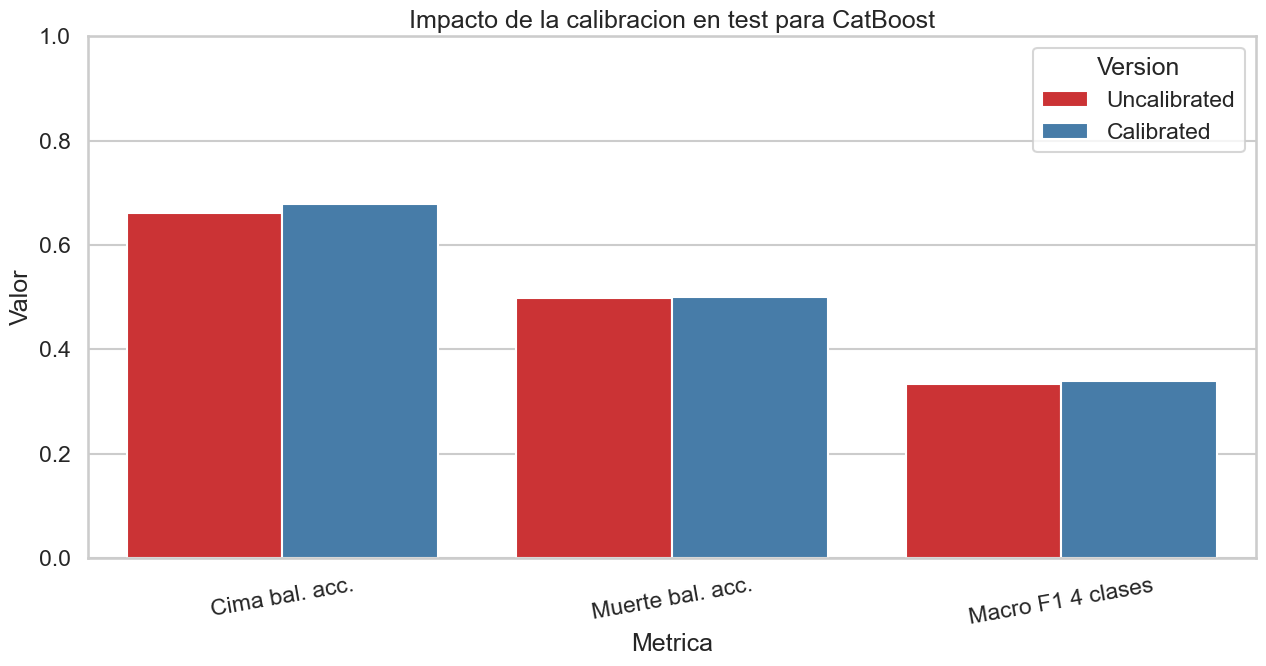

In [8]:
calibration_compare = pd.DataFrame([
    {
        'metric': 'Cima bal. acc.',
        'Uncalibrated': cat_test['summit_metrics']['balanced_accuracy'],
        'Calibrated': cat_test_cal['summit_metrics']['balanced_accuracy'],
    },
    {
        'metric': 'Muerte bal. acc.',
        'Uncalibrated': cat_test['death_metrics']['balanced_accuracy'],
        'Calibrated': cat_test_cal['death_metrics']['balanced_accuracy'],
    },
    {
        'metric': 'Macro F1 4 clases',
        'Uncalibrated': cat_test['outcome_4_metrics']['macro_f1'],
        'Calibrated': cat_test_cal['outcome_4_metrics']['macro_f1'],
    },
])

calibration_long = calibration_compare.melt(id_vars='metric', var_name='variant', value_name='value')

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=calibration_long, x='metric', y='value', hue='variant', palette='Set1', ax=ax)
ax.set_title('Impacto de la calibracion en test para CatBoost')
ax.set_xlabel('Metrica')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.legend(title='Version')
plt.tight_layout()
plt.show()

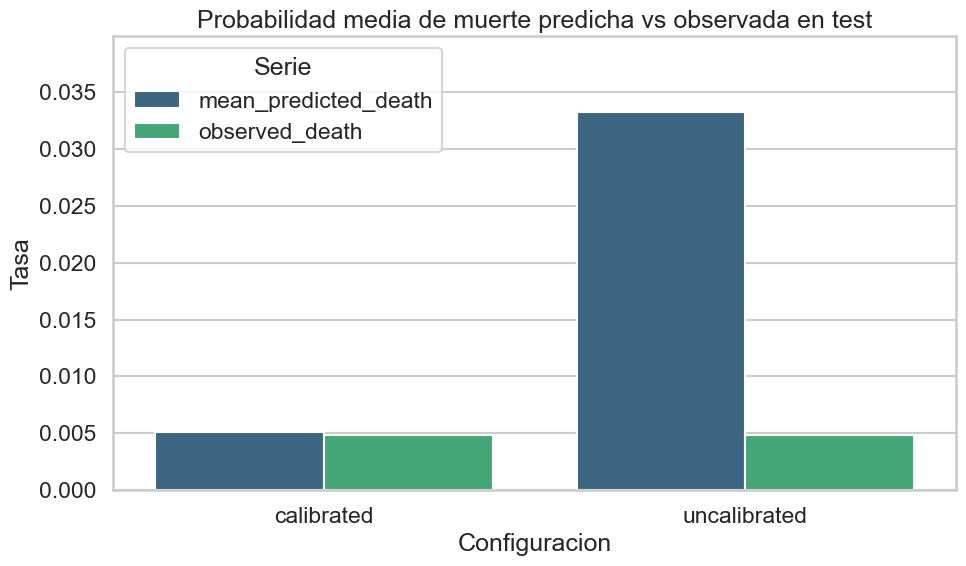

,calibration,mean_predicted_death,observed_death
0,calibrated,0.005146,0.004854
1,uncalibrated,0.033253,0.004854


In [9]:
pred_test = catboost_preds[catboost_preds['split'] == 'test'].copy()
pred_test['predicted_death'] = pred_test['p_death']
pred_test['real_death'] = pred_test['outcome_4'].isin(['cima_muere', 'abandona_muere'])

summary_death_prob = pred_test.groupby('calibration').agg(
    mean_predicted_death=('predicted_death', 'mean'),
    observed_death=('real_death', 'mean')
).reset_index()

summary_long = summary_death_prob.melt(id_vars='calibration', var_name='type', value_name='rate')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=summary_long, x='calibration', y='rate', hue='type', palette='viridis', ax=ax)
ax.set_title('Probabilidad media de muerte predicha vs observada en test')
ax.set_xlabel('Configuracion')
ax.set_ylabel('Tasa')
ax.set_ylim(0, max(summary_long['rate'].max() * 1.2, 0.02))
plt.legend(title='Serie')
plt.tight_layout()
plt.show()

summary_death_prob

## Conclusiones finales

1. El problema mas facil de modelar es la probabilidad de hacer cima; el mas dificil es la muerte.
2. La base esta muy desbalanceada, por eso accuracy alta en muerte no significa un modelo realmente util.
3. La region importa: hay diferencias claras entre macrorregiones en exito y riesgo.
4. La ocupacion aporta senal descriptiva, pero su alta tasa de faltantes limita su peso inferencial.
5. CatBoost es un avance razonable sobre el baseline para cima y para el esquema de 4 clases, pero no resuelve todavia los eventos raros.
6. La siguiente mejora seria atacar especificamente la rareza de `cima_muere` y `abandona_muere` con estrategias de costo, muestreo, thresholds o un enfoque orientado a ranking de riesgo.